In [7]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cette partie permet d'importer tes propres scripts situés dans le dossier 'src'
# On remonte d'un niveau pour trouver le dossier racine du projet
sys.path.append(os.path.abspath(os.path.join('..')))

# Importation de ta fonction de chargement de données NBA
try:
    from src.data import load_dataset_split
    print("✅ Modules importés avec succès !")
except ImportError as e:
    print(f"❌ Erreur d'importation : {e}")
    print("Vérifie que tu es bien dans le dossier 'ml-poc-project'")

✅ Modules importés avec succès !


In [8]:
# Appel de ta fonction pour récupérer les données de LeBron James
X_train, X_test, y_train, y_test = load_dataset_split()

# Affichage des premières lignes pour comprendre la structure
print(f"Nombre de matchs pour l'entraînement : {len(X_train)}")
print(f"Variables utilisées (Features) : {list(X_train.columns)}")

# Afficher un aperçu des données
X_train.head()

🚀 Récupération massive des données de la ligue...
✅ Saison 2020-21 récupérée.
✅ Saison 2021-22 récupérée.
✅ Saison 2022-23 récupérée.
✅ Saison 2023-24 récupérée.
✅ Saison 2024-25 récupérée.
📊 Dataset final : 58459 matchs et 19 colonnes.
Nombre de matchs pour l'entraînement : 46767
Variables utilisées (Features) : ['MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PLUS_MINUS']


,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PLUS_MINUS
110445,37.0,4,9,0.444,1,3,0.333,6,6,1.0,3,6,9,0,1,4,3,2,10
104364,35.0,5,16,0.313,3,6,0.500,9,9,1.0,0,4,4,8,2,0,7,2,7
26941,30.0,11,17,0.647,4,8,0.500,3,3,1.0,2,5,7,2,2,1,0,3,19
69029,29.0,8,15,0.533,0,4,0.000,1,1,1.0,0,2,2,2,1,0,1,2,-1
48546,26.0,5,11,0.455,1,3,0.333,1,2,0.5,3,3,6,3,0,0,2,4,-14


In [9]:
# Rechargement des nouvelles données massives
X_train, X_test, y_train, y_test = load_dataset_split()

# Création d'un DataFrame complet pour le nettoyage
df_train = X_train.copy()
df_train['PTS'] = y_train

# 1. Suppression des outliers (matchs où le joueur s'est blessé ou a très peu joué)
df_train = df_train[df_train['MIN'] > 5]

# 2. Feature Engineering : Points par Minute (PPM) 
# Cela permet de comparer l'efficacité peu importe le temps de jeu
df_train['PPM'] = df_train['PTS'] / df_train['MIN']

# 3. Corrélation : On vérifie mathématiquement quelles variables influencent les points
correlation_matrix = df_train.corr()
print("Corrélation avec les Points :")
print(correlation_matrix['PTS'].sort_values(ascending=False))

print(f"\nNouveau volume de données : {len(df_train)} matchs")

🚀 Récupération massive des données de la ligue...
✅ Saison 2020-21 récupérée.
✅ Saison 2021-22 récupérée.
✅ Saison 2022-23 récupérée.
✅ Saison 2023-24 récupérée.
✅ Saison 2024-25 récupérée.
📊 Dataset final : 58459 matchs et 19 colonnes.
Corrélation avec les Points :
PTS           1.000000
FGM           0.957354
FGA           0.853879
PPM           0.840594
MIN           0.644138
FG3M          0.612177
FTM           0.581248
FTA           0.569570
FG3A          0.548493
FG_PCT        0.443786
AST           0.384209
TOV           0.358764
DREB          0.338667
REB           0.321651
FG3_PCT       0.312903
PLUS_MINUS    0.196419
STL           0.167183
FT_PCT        0.150453
PF            0.132698
OREB          0.109600
BLK           0.099386
Name: PTS, dtype: float64

Nouveau volume de données : 46655 matchs


In [10]:
# Calcul du pourcentage de valeurs manquantes par colonne
missing_stats = df_train.isna().mean() * 100

print("--- ANALYSE DES DONNÉES MANQUANTES ---")
print(missing_stats)

# Vérification du critère des 5%
to_drop = missing_stats[missing_stats > 5].index.tolist()
if to_drop:
    print(f"\n⚠️ colonnes à supprimer (>5% de manque) : {to_drop}")
    # df_train = df_train.drop(columns=to_drop)
else:
    print("\n✅ Aucune feature ne dépasse 5% de données manquantes.")

--- ANALYSE DES DONNÉES MANQUANTES ---
MIN           0.0
FGM           0.0
FGA           0.0
FG_PCT        0.0
FG3M          0.0
FG3A          0.0
FG3_PCT       0.0
FTM           0.0
FTA           0.0
FT_PCT        0.0
OREB          0.0
DREB          0.0
REB           0.0
AST           0.0
STL           0.0
BLK           0.0
TOV           0.0
PF            0.0
PLUS_MINUS    0.0
PTS           0.0
PPM           0.0
dtype: float64

✅ Aucune feature ne dépasse 5% de données manquantes.


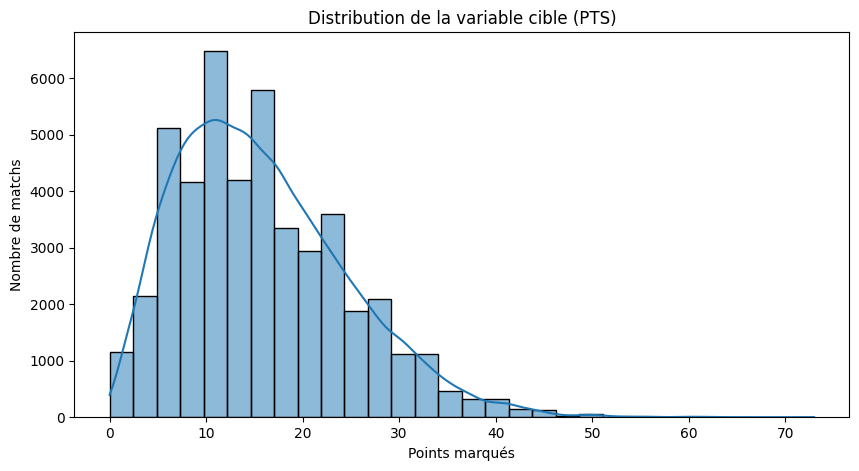

--- BIAIS DE LA CIBLE ---
Moyenne de points : 15.81
Médiane de points : 15.00


In [11]:
plt.figure(figsize=(10, 5))
sns.histplot(df_train['PTS'], bins=30, kde=True)
plt.title("Distribution de la variable cible (PTS)")
plt.xlabel("Points marqués")
plt.ylabel("Nombre de matchs")
plt.show()

# Vérification du biais
print("--- BIAIS DE LA CIBLE ---")
print(f"Moyenne de points : {df_train['PTS'].mean():.2f}")
print(f"Médiane de points : {df_train['PTS'].median():.2f}")

In [12]:
# On crée le fichier CSV localement
df_train.to_csv('../data/nba_raw_data.csv', index=False)
print("✅ Données sauvegardées dans le dossier /data")

✅ Données sauvegardées dans le dossier /data
